# CREATE SUPPLEMENTARY FIGURE 3E-H PANELS
## last updated: 08.01.25

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

In [3]:
%run 'ecDNAInspector_functions.ipynb'

In [4]:
# load path to cycle-level data table with clustering
cycle_level_data_clustered = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_clustered)

In [8]:
cohort_df

,Sample,Amplicon,Cycle,Cycle Type,Cycle Size (bp),Cycle Breakpoint Count,Cycle Chromosome Count,Cycle Regions List,Cycle Paired Ends List,Cycle TPR,...,Cycle Mapping Error Breakends,Cycle Unmappable Reasons,Small Deletions Count,Cycle Genes Info,Cycle Genes List,Cycle ESB,Cycle Type Boolean,Cycle Cluster Assignment,Selection Score,Confidence
0,CURTIS_H000381_T01_01_WG01,1,1,circular,855,1,1,"[('6', 44149194, 44150048)]","[('6', 44150048, '6', 44149194)]",0.0,...,"[('6', 44150048), ('6', 44149194)]","['High_Signal_Region', 'High_Signal_Region']",0,{},[],0.0,1,2,2.0625,low
1,CURTIS_H000382_T01_01_WG01,1,1,linear,20749,1,1,"[('8', 120335841, 120315091)]","[('8', 120315091, '8', 120335841)]",0.0,...,[],[],0,{},[],0.0,0,1,1.5000,medium
2,CURTIS_H000387_T01_01_WG01,1,1,linear,10741,1,1,"[('17', 71264685, 71253943)]","[('17', 71253943, '17', 71264685)]",0.0,...,[],[],0,{},[],0.0,0,1,1.5000,medium
3,CURTIS_H000387_T01_01_WG01,1,2,linear,210741,1,1,"[('17', 71124888, 70914146)]","[('17', 70914146, '17', 71124888)]",0.0,...,[],[],0,{},[],0.0,0,1,1.5000,medium
4,CURTIS_H000390_T01_01_WG01,1,1,linear,584698,1,1,"[('11', 69724499, 69139800)]","[('11', 69139800, '11', 69724499)]",0.0,...,[],[],0,"{'11': {'CCND1': {'type': ['oncogene', ' fusio...",['CCND1'],0.0,0,1,1.5000,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778,CURTIS_H002079_T01_01_WG01,2,25,linear,536,1,1,"[('1', 168186872, 168186335)]","[('1', 168186335, '1', 168186872)]",0.0,...,[],[],0,{},[],1.0,0,1,1.8750,medium
779,CURTIS_H002079_T01_01_WG01,2,26,linear,3329355,4,1,"[('8', 43091751, 42194367), ('8', 42190457, 40...","[('8', 42194367, '8', 42190457), ('8', 4077976...",0.0,...,"[('8', 43091751)]",['High_Signal_Region'],1,"{'8': {'ANK1': {'type': [''], 'loc': ('4151073...","['ANK1', 'HOOK3', 'IKBKB', 'KAT6A']",1.0,0,2,2.4375,low
780,CURTIS_H002079_T01_01_WG01,2,27,circular,692,2,1,"[('11', 99770820, 99771346), ('11', 99768921, ...","[('11', 99771346, '11', 99768921), ('11', 9976...",0.0,...,[],[],0,{},[],0.0,1,1,1.5000,medium
781,CURTIS_H002079_T01_01_WG01,2,28,linear,9369,2,1,"[('9', 31296865, 31292672), ('9', 31291355, 31...","[('9', 31292672, '9', 31291355), ('9', 3128617...",0.0,...,[],[],1,{},[],0.0,0,1,1.5000,medium


In [5]:
# show stability of filtering thresholds, scores, weights for output confidence sets

In [9]:
TPR_PFNR_thresholds = [0.3, 0.5, 0.7]
TPR_score_sets = [[2.0, 1.5, 1.0, 0.5], [1.5, 1.0, 0.5, 0], [1.0, 0.75, 0.5, 0]]
PFNR_score_sets = [[0.5, 1.0, 1.5, 2.0], [0, 0.5, 1.0, 1.5], [0, 0.5, 0.75, 1.0]]
MEB_score_sets = [[0.0, 0.5], [0.0, 0.75], [0.0, 1.0]]
ESB_score_sets = [[0.0, 0.5], [0.0, 0.75], [0.0, 1.0]]
weight_sets = [
    {"TPR": 1.0, "MEB": 0.75, "ESB": 0.5, "PFNR": 0.25}, 
    {"TPR": 1.0, "MEB": 1.0, "ESB": 1.0, "PFNR": 1.0},
    {"TPR": 1.0, "MEB": 0.5, "ESB": 0.5, "PFNR": 0.5}
]
total_score_thresholds_sets = [[1, 2], [0.5, 1], [1.5, 2.5]]

In [10]:
score_mapping = {"TPR": {"low": [1.0, 0.75, 0.5, 0], "medium": [1.5, 1.0, 0.5, 0], "high": [2.0, 1.5, 1.0, 0.5]}, 
                 "PFNR": {"low": [0, 0.5, 0.75, 1.0], "medium": [0, 0.5, 1.0, 1.5], "high": [0.5, 1.0, 1.5, 2.0]}, 
                 "MEB": {"low": [0.0, 0.5], "medium": [0.0, 0.75], "high": [0.0, 1.0]},
                 "ESB": {"low": [0.0, 0.5], "medium": [0.0, 0.75], "high": [0.0, 1.0]},
                 "total_score_thresholds": {"low": [0.5, 1], "medium": [1, 2], "high": [1.5, 2.5]},
                 "weights": {"equal": {"TPR": 1.0, "MEB": 1.0, "ESB": 1.0, "PFNR": 1.0},
                              "gradient": {"TPR": 1.0, "MEB": 0.75, "ESB": 0.5, "PFNR": 0.25},
                              "partial equal": {"TPR": 1.0, "MEB": 0.5, "ESB": 0.5, "PFNR": 0.5}},
                 "TPR_PFNR_thresholds": {"low": 0.3, "medium": 0.5, "high": 0.7}
                }

In [11]:
results = []

for TPR_scores, PFNR_scores, MEB_scores, ESB_scores, total_score_thresholds, weights, TPR_PFNR_threshold in itertools.product(
    score_mapping["TPR"].items(), score_mapping["PFNR"].items(), score_mapping["MEB"].items(), score_mapping["ESB"].items(), 
    score_mapping["total_score_thresholds"].items(), score_mapping["weights"].items(), score_mapping["TPR_PFNR_thresholds"].items()):

    selection_values = ["Cycle TPR", "Cycle MEB", "Cycle ESB", "Cycle PFNR"]

    temp_cohort_w_conf_df = post_clustering_hierarchical_selection(
        cohort_df, selection_values, 
        TPR_PFNR_threshold[1], TPR_PFNR_threshold[1], 
        TPR_scores[1], PFNR_scores[1], MEB_scores[1], ESB_scores[1], 
        total_score_thresholds[1], weights[1]
    )

    high_conf_count = (temp_cohort_w_conf_df["Confidence"] == "high").sum()

    results.append({
        "TPR_PFNR_threshold": TPR_PFNR_threshold[0],
        "TPR_scores": TPR_scores[0],
        "PFNR_scores": PFNR_scores[0],
        "MEB_scores": MEB_scores[0],
        "ESB_scores": ESB_scores[0],
        "weights": weights[0],
        "total_score_thresholds": total_score_thresholds[0],
        "high_conf_count": high_conf_count
    })

results_df = pd.DataFrame(results)

Total cycles with complete selection information: 783
Total high confidence cycles: 0
Total medium confidence cycles: 601
Total low confidence cycles: 182
Total cycles with complete selection information: 783
Total high confidence cycles: 0
Total medium confidence cycles: 595
Total low confidence cycles: 188
Total cycles with complete selection information: 783
Total high confidence cycles: 0
Total medium confidence cycles: 576
Total low confidence cycles: 207
Total cycles with complete selection information: 783
Total high confidence cycles: 0
Total medium confidence cycles: 618
Total low confidence cycles: 165
Total cycles with complete selection information: 783
Total high confidence cycles: 0
Total medium confidence cycles: 614
Total low confidence cycles: 169
Total cycles with complete selection information: 783
Total high confidence cycles: 0
Total medium confidence cycles: 604
Total low confidence cycles: 179
Total cycles with complete selection information: 783
Total high confi

In [17]:
results_df["high_conf_count"].value_counts()

high_conf_count
0      1053
205      85
204      74
198      74
135      72
       ... 
661       1
659       1
642       1
556       1
245       1
Name: count, Length: 144, dtype: int64

### Supp. Fig. 3E

In [12]:
# determine lower threshold (10%) for count of combinations with 0 high confidence cycles
min_0_count = int(len(results_df)*.10)

In [13]:
# determine upper threshold (20%) for count of combinations with 0 high confidence cycles
max_0_count = int(len(results_df)*.20)

In [14]:
results_df_zero = results_df[results_df["high_conf_count"] == 0]

In [18]:
results_df_zero

,TPR_PFNR_threshold,TPR_scores,PFNR_scores,MEB_scores,ESB_scores,weights,total_score_thresholds,high_conf_count
0,low,low,low,low,low,equal,low,0
1,medium,low,low,low,low,equal,low,0
2,high,low,low,low,low,equal,low,0
3,low,low,low,low,low,gradient,low,0
4,medium,low,low,low,low,gradient,low,0
...,...,...,...,...,...,...,...,...
2176,medium,high,high,high,high,partial equal,medium,0
2177,high,high,high,high,high,partial equal,medium,0
2178,low,high,high,high,high,equal,high,0
2179,medium,high,high,high,high,equal,high,0


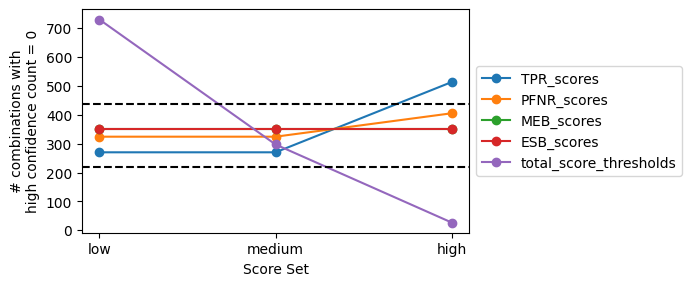

In [19]:
score_type_counts = results_df_zero.melt(
    value_vars=["TPR_scores", "PFNR_scores", "MEB_scores", "ESB_scores", "total_score_thresholds"],
    var_name="Score Type", value_name="Score Set"
).groupby(["Score Type", "Score Set"]).size().reset_index(name="Count")

score_type_counts_pivot = score_type_counts.pivot(index="Score Set", columns="Score Type", values="Count").fillna(0)

score_type_order = ["low", "medium", "high"]
score_type_counts_pivot = score_type_counts_pivot.reindex(score_type_order)

plt.figure(figsize=(5, 2.9))
for score_type in ["TPR_scores", "PFNR_scores", "MEB_scores", "ESB_scores", "total_score_thresholds"]:
    plt.plot(score_type_order, score_type_counts_pivot[score_type], marker='o', label=score_type.replace("_category", ""))

plt.axhline(y=min_0_count, linestyle="--", color="black")
plt.axhline(y=max_0_count, linestyle="--", color="black")

plt.xlabel("Score Set")
plt.ylabel("# combinations with\nhigh confidence count = 0")
plt.legend(title="Score Type")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [20]:
results_df_filt = results_df[(results_df["total_score_thresholds"] == "medium") & (results_df["TPR_scores"] != "high") & (results_df["PFNR_scores"] != "high")]

### Supp. Fig. 3F

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_62477/1402342184.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


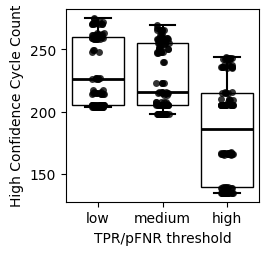

In [21]:
plt.figure(figsize=(2.5, 2.5))

sns.boxplot(
    x='TPR_PFNR_threshold', y='high_conf_count', data=results_df_filt, palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    x='TPR_PFNR_threshold', y='high_conf_count', data=results_df_filt, color='black', alpha=0.8, jitter=True
)

plt.xlabel("TPR/pFNR threshold")
plt.ylabel("High Confidence Cycle Count")

plt.show()

### Supp. Fig. 3G

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_62477/3185369342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


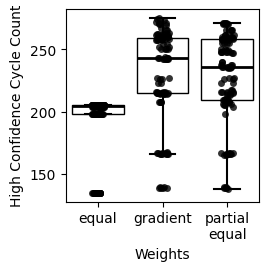

In [22]:
plt.figure(figsize=(2.5, 2.5))

sns.boxplot(
    x='weights', y='high_conf_count', data=results_df_filt, palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    x='weights', y='high_conf_count', data=results_df_filt, color='black', alpha=0.8, jitter=True
)

manual_labels = ["equal", "gradient", "partial\nequal"]
plt.xticks(ticks=range(len(manual_labels)), labels=manual_labels)

plt.xlabel("Weights")
plt.ylabel("High Confidence Cycle Count")

plt.show()

### Supp. Fig. 3H

In [23]:
subset_df = results_df_filt[(results_df_filt["TPR_scores"] == 'medium') & (results_df_filt["PFNR_scores"] == 'medium') & (results_df_filt["ESB_scores"] == 'medium') & (results_df_filt["MEB_scores"] == 'medium')]

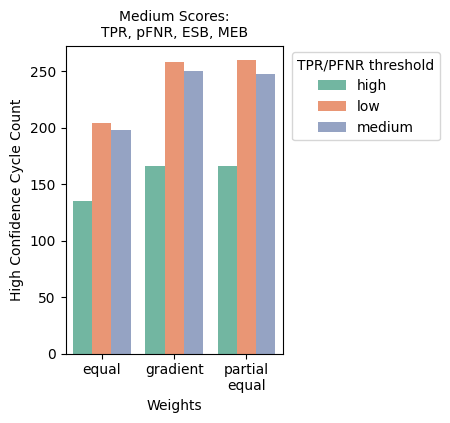

In [24]:
aggregated_data = subset_df.groupby(['weights', 'TPR_PFNR_threshold'])['high_conf_count'].sum().reset_index()

plt.figure(figsize=(2.8, 4))

sns.barplot(x='weights', y='high_conf_count', hue='TPR_PFNR_threshold', data=aggregated_data, palette="Set2")

plt.xlabel('Weights')
plt.ylabel('High Confidence Cycle Count')
plt.title('Medium Scores:\nTPR, pFNR, ESB, MEB', fontsize=10)

manual_labels = ["equal", "gradient", "partial\nequal"]
plt.xticks(ticks=range(len(manual_labels)), labels=manual_labels)

plt.legend(title='TPR/PFNR threshold', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.show()